In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d
%matplotlib inline
from ipywidgets import interact, fixed
import ipywidgets as widgets
from numba import njit, prange
from numba import float64, int32
from numba.experimental import jitclass
import pickle
from typing import List, Tuple, Callable, Any

from utils import MovingFunctionCalculator
from utils import Analytical
from utils import Plotter

In [8]:
class Plotter:
    @staticmethod
    def frame(grid: np.ndarray, kon: float, koff: float, kstep: float,q:float, sims: int, window: int = 1) -> None:
        """
        Plot simulation and analytical data.

        Parameters:
            grid (numpy.ndarray): The input grid.
            kon (float): On-rate.
            koff (float): Off-rate.
            kstep (float): Step rate.
            sims (int): Number of simulations.
            window (int, optional): Size of the moving window. Defaults to 1.
        """
        avg = MovingFunctionCalculator.custom_func(grid, window, np.mean)
        std = MovingFunctionCalculator.custom_func(grid, window, np.std)

        # prob = Analytical.normalised_P(koff, kstep, grid)
        # theo2 = Analytical.calc_P(kon, koff, kstep, grid)
        theo3 = Analytical.calc_P_3(q*kon, koff, kstep, grid)
        # theo = np.sum(grid) * prob

        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        ax.plot(avg, label='simulation')
        # ax.plot(theo, c='grey', linestyle='-', label='analytical')
        # ax.plot(theo2, c='r', linestyle='-.', label='analytical2')
        ax.plot(theo3, c='r', linestyle='-.', label='analytical')

        ax.fill_between(range(len(avg)), avg - std, avg + std, color='lightblue', alpha=0.5)
        ax.set(title=f'Total num of kinesins={int(np.sum(grid))} \n Average over {sims} sims', ylim=[0, 4])
        ax.grid()
        ax.legend(loc=(0.805, 0.125))
        plt.show()

In [2]:
@njit
def activation_to_factors(L, q, grid_activated)->np.ndarray[Any, np.dtype[np.float64]]:
    return np.ones(L) + (q-1) * grid_activated


@njit
def calc_propensities(L, grid:np.ndarray[Any, np.dtype[np.float64]], 
                      grid_activated:np.ndarray[Any, np.dtype[np.float64]],
                      kon, koff, kstep, kq, q):
    
    n_on = np.sum(activation_to_factors(L, q, grid_activated))
    n_off = np.sum(grid)
    n_step = np.sum(grid)

    aon = n_on*kon
    aoff = n_off*koff
    astep = n_step*kstep
    aq = kq * len(np.where((grid_activated==1)&(grid==0))[0])

    return np.array([aon, aoff, astep, aq])


@njit
def bind_kinesin(L, q, grid: np.ndarray[Any, np.dtype[np.float64]],
                 grid_activated:np.ndarray[Any, np.dtype[np.float64]]) -> None:
    
    S = np.cumsum(activation_to_factors(L, q, grid_activated))
    r = S[-1]*np.random.random()
    side = np.argmax(S>=r)
    grid[side] += 1

@njit
def unbind_kinesin(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    S = np.cumsum(grid)
    r = np.random.randint(low = 1, high = int(S[-1])+1)
    side = np.argmax(S>=r)

    grid[side] -= 1

@njit
def move_kinesin_w_fall(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    S = np.cumsum(grid)
    r = np.random.randint(low = 1, high = int(S[-1])+1)
    side = np.argmax(S>=r)

    grid[side] -= 1
    if side != len(grid)-1:
        grid[side+1] += 1

@njit
def deactivate_tubule(grid, grid_activated)->None:
    sides = np.where((grid_activated==1)&(grid==0))[0]
    S = len(sides)
    r = np.random.randint(S)
    side = sides[r]
    grid_activated[side]=0

@njit
def activate_tubule(grid, grid_activated)->None:
    sides = np.where((grid!=0))
    grid_activated[sides]=1
    return grid_activated



@njit
def step(L, grid, grid_activated, kon, koff, kstep, kq, q)->Tuple[float, int]:
    r1 = np.random.uniform()
    r2 = np.random.uniform()

    A = calc_propensities(L, grid, grid_activated, kon, koff, kstep, kq, q)
    R_tot = np.sum(A)
    
    A_normalised = np.cumsum(A)/R_tot

    dt = (1/R_tot) * np.log(1/r1)
    idx = np.argwhere(A_normalised>r2)[0][0]
    return dt, int(idx)

@njit
def simulation(L,T, kon, koff, kstep, kq, q):
    time = 0.0
    block = 0
    period = 0.1
    next_write_time = period
    blocks = int(T/period)

    grid:np.ndarray[Any, np.dtype[np.float64]] = np.zeros(L)
    grid_activated = np.zeros(L,dtype=np.float64 )


    DATA = np.zeros((blocks, L))
    TIMES= np.zeros(blocks)

    while time<T:
        dt, idx = step(L, grid, grid_activated, kon, koff, kstep, kq, q)
        time+= dt      

        # Action
        if idx==0:
            bind_kinesin(L, q,  grid, grid_activated)
        elif idx==1:
            unbind_kinesin(grid)
        elif idx==2:
            move_kinesin_w_fall(grid)
        else:
            deactivate_tubule(grid, grid_activated)

        grid_activated = activate_tubule(grid, grid_activated)
        
        
        #Write    
        if next_write_time<time:
            DATA[block,:] = grid
            TIMES[block] = time
            block+=1
            next_write_time+=period

    return DATA[:block], TIMES[:block]

In [4]:
@njit(parallel=True)
def multiple_SIMS_last(num, L, T, kon, koff, kstep, kq, q):

    LAST_FRAMES = np.zeros((num, L))
    for i in prange(num):
        DATA, TIMES = simulation(L, T, kon, koff, kstep, kq, q)
        LAST_FRAMES[i,:]=DATA[-1,:]
    return LAST_FRAMES

In [3]:
L = 300
T = 20
kon = 0.5
koff = 1
kstep = 10
kq = 1
q = 10

In [5]:
data, times = simulation(L, T, kon, koff, kstep, kq, q)

In [6]:
newframes= multiple_SIMS_last(50, L, T, kon, koff, kstep, kq, q)

In [7]:
sims = len(newframes)
avg_over_sims = np.mean(newframes, axis=0)

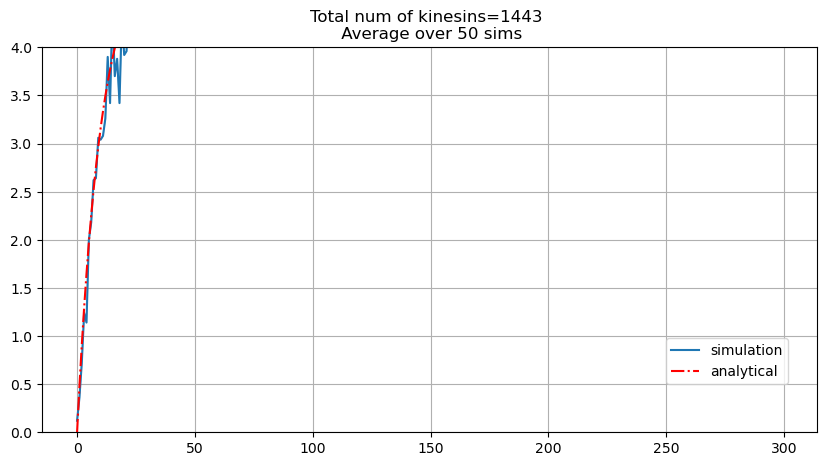

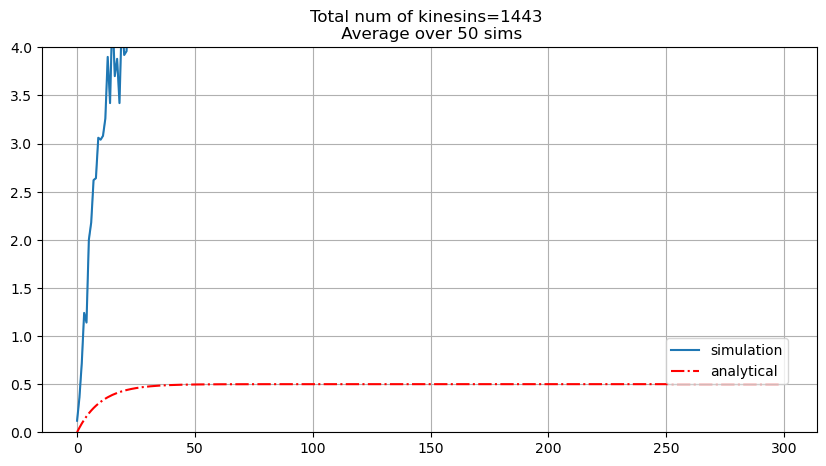

In [9]:
Plotter.frame(avg_over_sims, kon, koff, kstep, q,sims)
Plotter.frame(avg_over_sims, kon, koff, kstep, 1,sims)

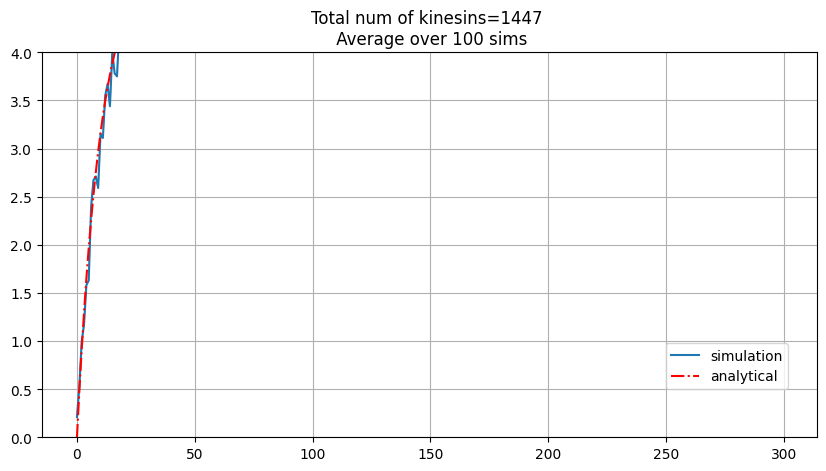

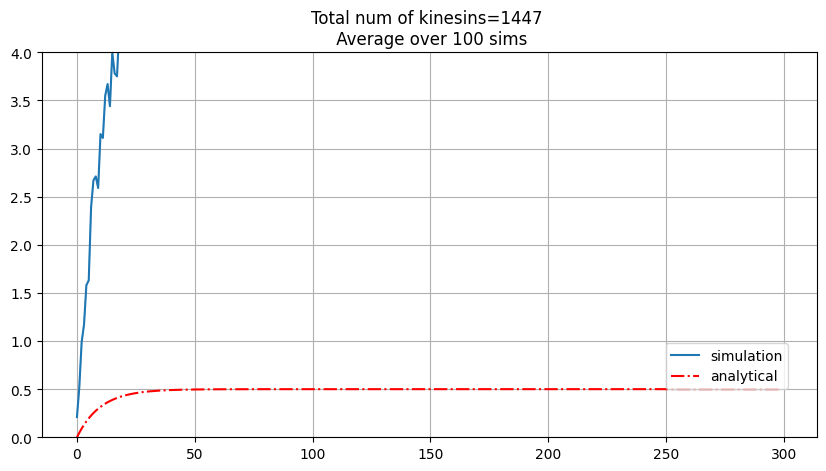

In [58]:
Plotter.frame(avg_over_sims, kon, koff, kstep, q,sims)
Plotter.frame(avg_over_sims, kon, koff, kstep, 1,sims)

In [25]:
avg_over_sims.mean()

1.2061666666666668

In [26]:
avg_over_sims.var()

0.041488305555555556